# Exercises in Clustering

## Exercise 1

In this exercise, we will use a bike sharing dataset. The dataset contains coordinates of bike sharing stations in New York given as longitude and latitude values.

The dataset is an example dataset from the book ["Introduction to R for Business Intelligence"](https://jgendron.github.io/com.packtpub.intro.r.bi/), Packt Publishing Ltd., 2016, by Jay Gendron. The dataset is downloadable from Github [here](https://github.com/jgendron/com.packtpub.intro.r.bi/tree/master/Chapter5-ClusteringAnalysis/data), but is also available on Moodle as "Ch5_bike_station_locations.csv".

Answer the following questions:
1. Apply K-Means clustering to the dataset. Try out different values for K and use the Elbow method to find the best (or a sensible) K.
2. Visualize the K-Means clustering result for the best K.
3. Apply Agglomerative clustering to the dataset. Draw the Dendrogram and use it to find the best (or a sensible) number of clusters.
4. Generate this number of clusters with Agglomerative clustering and visualize the clustering.
5. Apply DBSCAN clustering to the dataset. Try out different values for "eps" and "min_samples" and choose the best values. (Hint: For "eps" you probably have to try out values around 0.01.)
6. Visualize the final DBSCAN clustering you decided upon in 5.
7. Calculate the Silhouette scores for the three different "best clustering" you found with the three different methods. Also use Adjusted Rand Index to compare the best ones to each other.

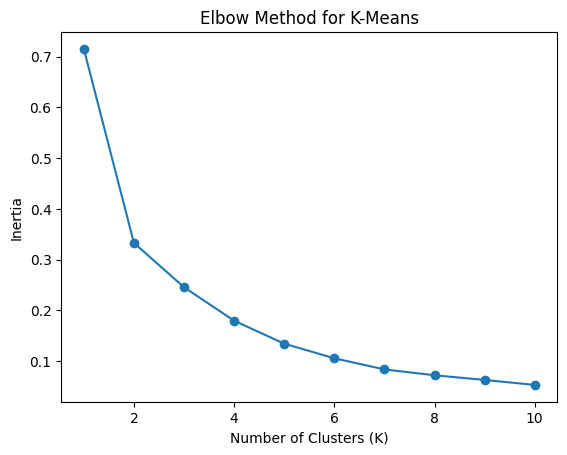

In [3]:
#01


import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Load your dataset
df = pd.read_csv(r"C:\Users\LENOVO\Downloads\Ch5_bike_station_locations.csv")  
X = df[['longitude', 'latitude']]  

inertia = []  
K_range = range(1, 11)  

for K in K_range:
    kmeans = KMeans(n_clusters=K, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

# Plot the Elbow curve
plt.plot(K_range, inertia, marker='o')
plt.title('Elbow Method for K-Means')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.show()

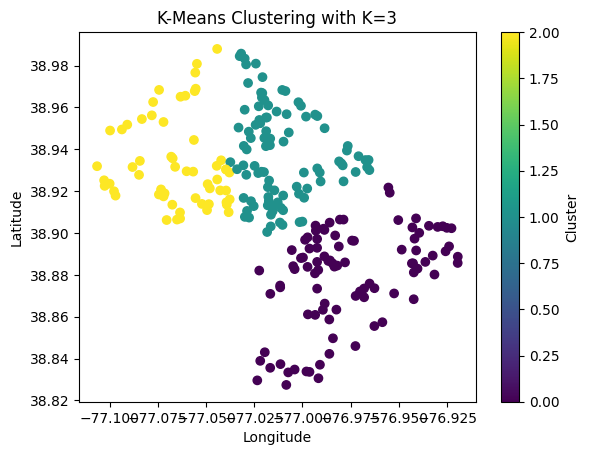

In [4]:
#02

best_k = 3 
kmeans = KMeans(n_clusters=best_k, random_state=42)
df['cluster'] = kmeans.fit_predict(X)

# Visualize the clusters
plt.scatter(df['longitude'], df['latitude'], c=df['cluster'], cmap='viridis')
plt.title(f'K-Means Clustering with K={best_k}')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.colorbar(label='Cluster')
plt.show()

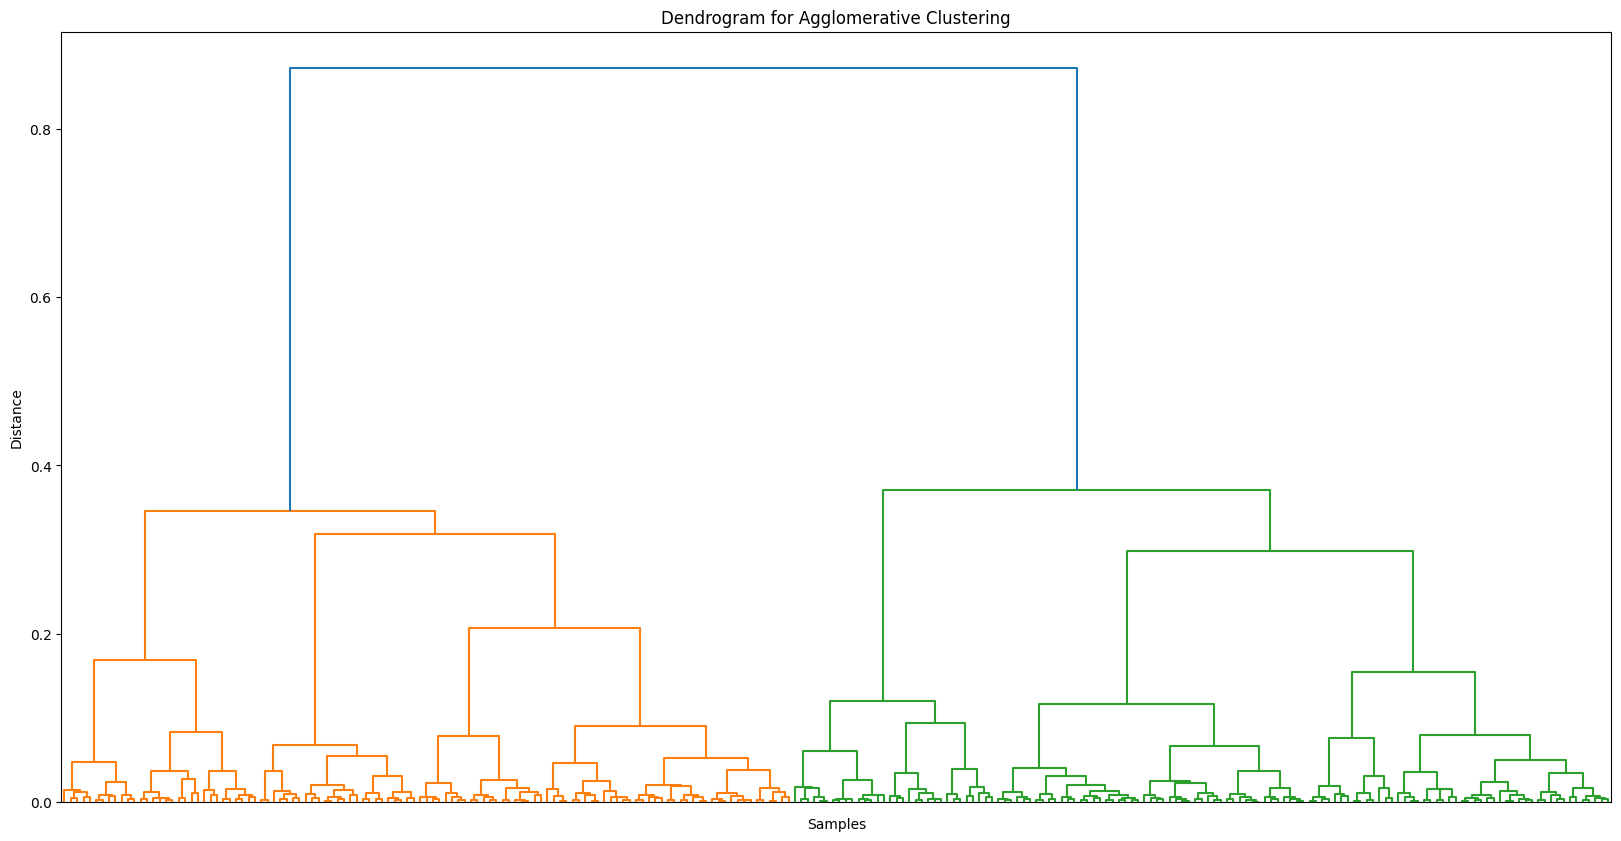

In [7]:
#03


import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering

# Agglomerative Clustering - Dendrogram with improved visibility
plt.figure(figsize=(20, 10))  # Increase the figure size significantly
dendrogram = sch.dendrogram(sch.linkage(X, method='ward'))

# Adjusting axis labels for better readability
plt.title('Dendrogram for Agglomerative Clustering')
plt.xlabel('Samples')
plt.ylabel('Distance')

# Display every 10th x-axis label for better readability
plt.xticks(range(0, len(X), 10), rotation=90)  # Rotate x-axis labels and show every 10th label

plt.show()
plt.show()

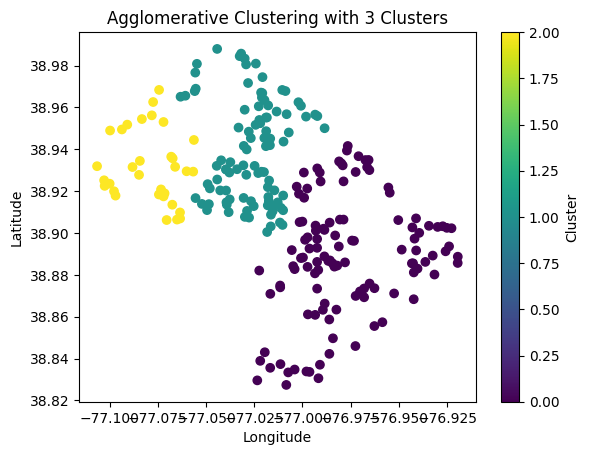

In [8]:
#04


agg_clust = AgglomerativeClustering(n_clusters=best_clusters)
df['agg_cluster'] = agg_clust.fit_predict(X)

# Visualize the clusters
plt.scatter(df['longitude'], df['latitude'], c=df['agg_cluster'], cmap='viridis')
plt.title(f'Agglomerative Clustering with {best_clusters} Clusters')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.colorbar(label='Cluster')
plt.show()

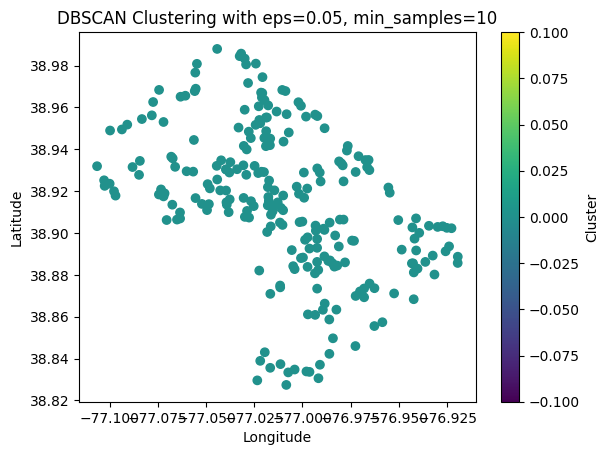

In [11]:
#05


from sklearn.cluster import DBSCAN

eps_values = [0.01, 0.05, 0.1] 
min_samples_values = [5, 10, 15]

best_eps = 0.05
best_min_samples = 10 

dbscan = DBSCAN(eps=best_eps, min_samples=best_min_samples)
df['dbscan_cluster'] = dbscan.fit_predict(X)

plt.scatter(df['longitude'], df['latitude'], c=df['dbscan_cluster'], cmap='viridis')
plt.title(f'DBSCAN Clustering with eps={best_eps}, min_samples={best_min_samples}')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.colorbar(label='Cluster')
plt.show()

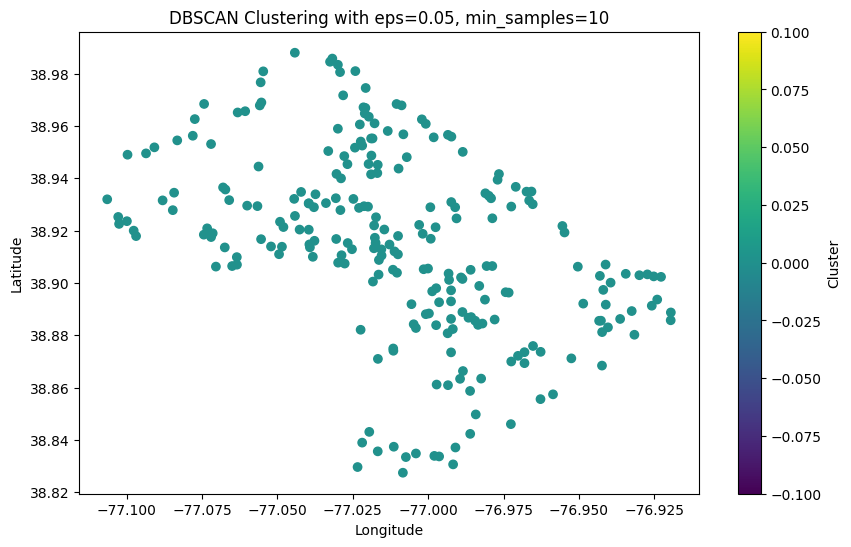

In [12]:
#06


from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

# Final optimal parameters for DBSCAN
best_eps = 0.05  # Replace with the best eps you found
best_min_samples = 10  # Replace with the best min_samples you found

# Apply DBSCAN clustering with the chosen eps and min_samples
dbscan = DBSCAN(eps=best_eps, min_samples=best_min_samples)
df['dbscan_cluster'] = dbscan.fit_predict(X)

# Visualize the DBSCAN clustering result
plt.figure(figsize=(10, 6))
plt.scatter(df['longitude'], df['latitude'], c=df['dbscan_cluster'], cmap='viridis')
plt.title(f'DBSCAN Clustering with eps={best_eps}, min_samples={best_min_samples}')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.colorbar(label='Cluster')
plt.show()

In [14]:
# Check how many points are labeled as noise (-1)
num_noise_points = sum(df['dbscan_cluster'] == -1)
print(f'Number of noise points: {num_noise_points}')

# Check how many clusters are identified
num_clusters = len(set(df['dbscan_cluster'])) - (1 if -1 in df['dbscan_cluster'].values else 0)
print(f'Number of clusters found: {num_clusters}')

Number of noise points: 0
Number of clusters found: 1


In [18]:
#07


from sklearn.metrics import silhouette_score

filtered_labels = df['dbscan_cluster'][df['dbscan_cluster'] != -1]
filtered_X = X[df['dbscan_cluster'] != -1]

if len(set(filtered_labels)) > 1:
    dbscan_silhouette = silhouette_score(filtered_X, filtered_labels)
    print(f'Silhouette Score for DBSCAN: {dbscan_silhouette}')
else:
    print("DBSCAN detected fewer than 2 clusters. Silhouette score cannot be calculated.")

DBSCAN detected fewer than 2 clusters. Silhouette score cannot be calculated.
